In [5]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
from ratansunpy.client import RATANClient
from ratansunpy.utils import get_project_root
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from ratansunpy.core.ar_handling import ARHandler
from ratansunpy.time import TimeRange 
from astropy.io.fits.verify import VerifyWarning
from astropy.table import Table
from typing import Dict, Tuple, Any
from ratansunpy.client import SRSClient
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'ratansunpy'

In [13]:
ROOT_DIR = Path(os.getcwd()).parent
DATE = "20170903_121257"
print(ROOT_DIR)

/home/max/RATANSunPy-ar_extraction


In [14]:
processed_path = ROOT_DIR/"data"/"RATAN_data"/"2017"/f"{DATE}_sun+0_out_processed.fits"
processed_hdul = fits.open(processed_path)

In [15]:
base_path = get_project_root()/"data"/"SRS_data"
base_url = str(base_path) + '/%Y_SRS/%Y%m%dSRS.txt'

In [16]:
ratan_client = RATANClient()
srs_table = ratan_client.form_srstable_with_time_shift(processed_hdul, base_url)

handler = ARHandler(processed_hdul, srs_base_url=base_url)

In [ ]:
def extract_area_lat_dict(table, key_col="Number", val_col="Latitude") -> dict:

    required_columns = {key_col, val_col}
    
    if not required_columns.issubset(table.columns):
        missing_columns = required_columns - set(table.columns)
        raise ValueError(f"Missing required columns in the table: {missing_columns}")
    
    return dict(zip(table[key_col], table[val_col]))

def plot_masked_areas(ares_dict: dict, handler: ARHandler, output_dir: str):

    for area, lat in ares_dict.items():

        area_windowed = handler.extract_ar_data_with_window(latitude=lat)
        
        plt.figure(figsize=(12, 5))
        
        plt.suptitle(f"Area: {area}, Latitude: {lat}", fontsize=14, y=1.05)
        
        plt.subplot(131)
        plt.imshow(area_windowed[0])
        plt.title("I value across FREQ")
        
        plt.subplot(132)
        plt.imshow(area_windowed[1])
        plt.title("V value across FREQ")
        
        plt.tight_layout()

        os.makedirs(output_dir, exist_ok=True)
        filename = f"{area}_{lat}.png"
        plt.savefig(os.path.join(output_dir, filename),
                    dpi=300,
                    bbox_inches='tight')
        

In [113]:
area_lat_dict = extract_area_lat_dict(srs_table)

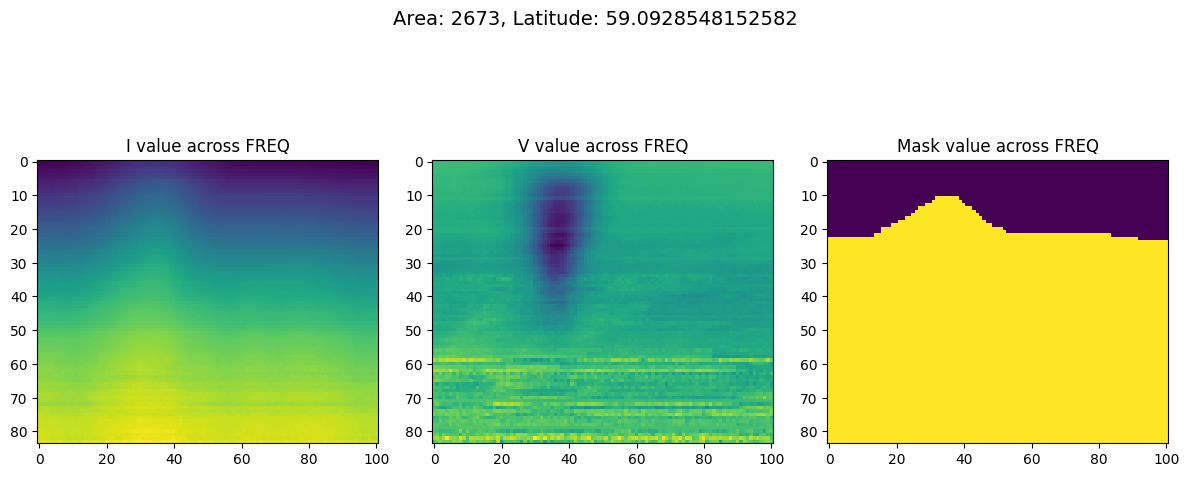

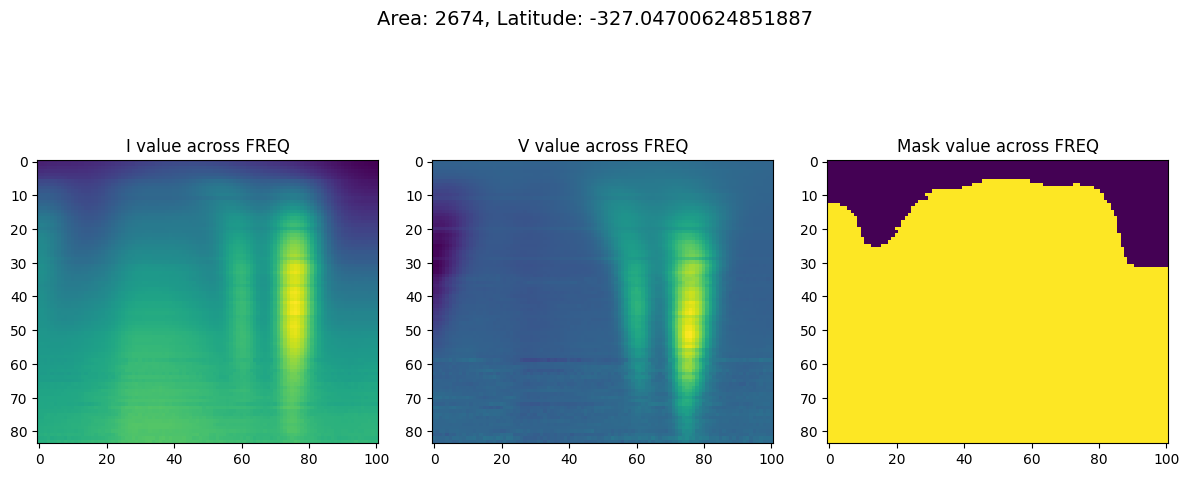

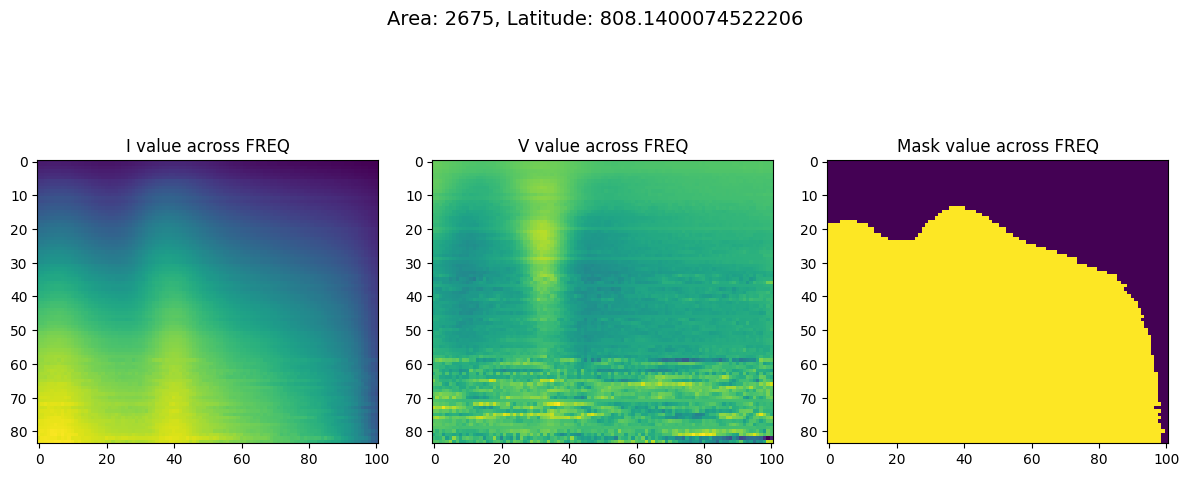

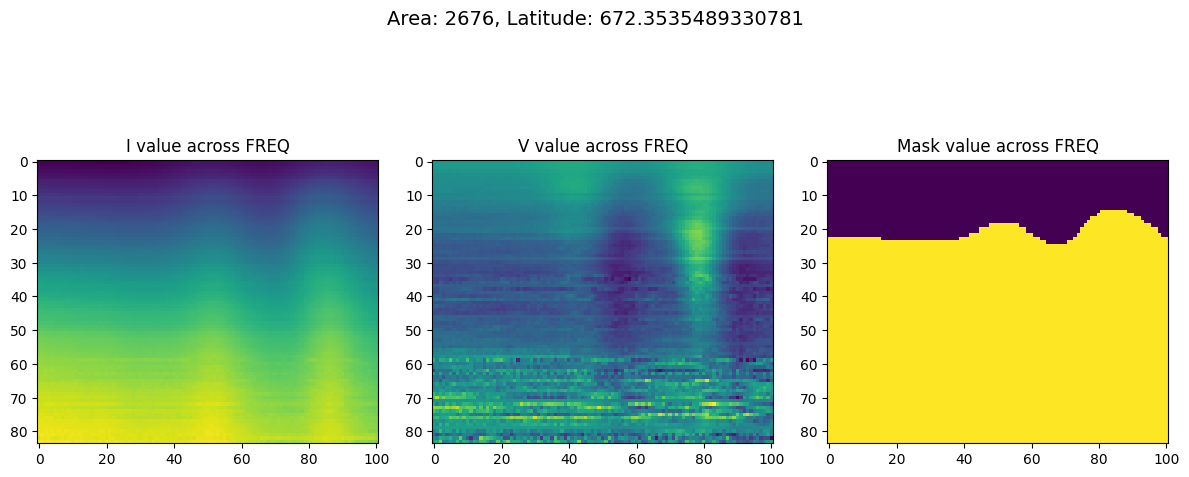

In [114]:
plot_masked_areas(ares_dict=area_lat_dict,
                  handler=handler,
                  output_dir=os.path.join("plots", DATE))